In [1]:
import numpy
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [2]:
torch.manual_seed(42)  # For reproducibility

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
from pathlib import Path

base = Path("data/prepared_data256")

print("Czy istnieje base?", base.exists())
print("Czy istnieje images?", (base / "images").exists())
print("Czy istnieje masks?", (base / "masks").exists())

print("Pliki w base:")
print(list(base.glob("*")))

print("Pliki w images:")
print(list((base / "images").glob("*"))[:10])

print("Pliki w masks:")
print(list((base / "masks").glob("*"))[:10])

Czy istnieje base? False
Czy istnieje images? False
Czy istnieje masks? False
Pliki w base:
[]
Pliki w images:
[]
Pliki w masks:
[]


In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split

images = sorted(Path("data/prepared_data256/images").glob("*.png"))
masks = sorted(Path("data/prepared_data256/masks").glob("*.png"))

pairs = list(zip(images, masks))
print(pairs)
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

In [60]:
import random
import torchvision.transforms.functional as TF

class SegementationTransform():
    def __init__(self,hflip_prob=0.5,vflip_prob=0.5):
        self.hflip_prob = hflip_prob
        self.vflip_prob =vflip_prob

In [61]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF


class AerialSegemntationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        return image, mask

In [62]:
from torch.utils.data import DataLoader

train_dataset = AerialSegemntationDataset(train_pairs)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True,num_workers=0)

val_dataset = AerialSegemntationDataset(val_pairs)

val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False,num_workers=0)

test_dataset = AerialSegemntationDataset(test_pairs)

test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False,num_workers=0)

In [63]:
class UNet(nn.Module):
    def __init__(self, n_class,inuput_channels):
        super().__init__()
        #Encoding
        self.e11 = nn.Conv2d(inuput_channels, 64, kernel_size=3, padding=1, bias=False)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.pool3 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False)
        self.pool4 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False)

        #Decoding
        self.upconv1 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.d11 = nn.Conv2d(1024,512,kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512,512,kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.d21 = nn.Conv2d(512,256,kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256,256,kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.d31 = nn.Conv2d(256,128,kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128,128,kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.d41 = nn.Conv2d(128,64,kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64,64,kernel_size=3, padding=1)

        #out
        self.outconv= nn.Conv2d(64,n_class,kernel_size=1)

    def forward(self,x):
        #encoder
        xe11 = nn.functional.relu(self.e11(x))
        xe12 = nn.functional.relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = nn.functional.relu(self.e21(xp1))
        xe22 = nn.functional.relu(self.e22(xe21))
        xp2 = self.pool1(xe22)

        xe31 = nn.functional.relu(self.e31(xp2))
        xe32 = nn.functional.relu(self.e32(xe31))
        xp3 = self.pool1(xe32)

        xe41 = nn.functional.relu(self.e41(xp3))
        xe42 = nn.functional.relu(self.e42(xe41))
        xp4 = self.pool1(xe42)

        xe51 = nn.functional.relu(self.e51(xp4))
        xe52 = nn.functional.relu(self.e52(xe51))

        #decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1,xe42],dim=1)
        xd11 = nn.functional.relu(self.d11(xu11))
        xd12 = nn.functional.relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu21 = torch.cat([xu2,xe32],dim=1)
        xd21 = nn.functional.relu(self.d21(xu21))
        xd22 = nn.functional.relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu31 = torch.cat([xu3,xe22],dim=1)
        xd31 = nn.functional.relu(self.d31(xu31))
        xd32 = nn.functional.relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu41 = torch.cat([xu4,xe12],dim=1)
        xd41 = nn.functional.relu(self.d41(xu41))
        xd42 = nn.functional.relu(self.d42(xd41))

        #out
        out = self.outconv(xd42)

        return out

        

In [64]:
from torchmetrics.classification import MulticlassJaccardIndex

class Trainer():
    def __init__(self,
                 model,
                 train_loader,
                 val_loader,
                 test_loader,
                 criterion,
                 optimizer,
                 num_epochs,
                 metric = MulticlassJaccardIndex(num_classes=6, average=None)
):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.num_epochs = num_epochs
        self.metric = metric.to(device=device)

        self.train_loss_hist =[]
        self.val_loss_hist =[]
        self.train_miou_hist =[]
        self.val_miou_hist =[]

    def training_epoch(self, data_loader):
        self.model.train()
        running_loss = 0.0
        
        self.metric.reset()
        for image, mask in data_loader:
            image, mask = image.to(device), mask.to(device)

            self.optimizer.zero_grad()
            out = self.model(image)
            loss = self.criterion(out,mask)
            loss.backward()
            self.optimizer.step()
            

            running_loss += loss.item()
            pred = torch.argmax(out, dim=1)

            self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()

    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        self.metric.reset()
        
        with torch.no_grad():
            for image, mask in data_loader:
                image, mask = image.to(device), mask.to(device)

                out = self.model(image)
                loss = self.criterion(out,mask)

                running_loss += loss.item()
                pred = torch.argmax(out, dim=1)

                self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()
    

    def train(self):

        for epoch in range(self.num_epochs):
            train_loss, train_miou = self.training_epoch(self.train_loader)
            val_loss, val_miou = self.evaluate(self.val_loader)

            self.train_loss_hist.append(train_loss)
            self.val_loss_hist.append(val_loss)
            self.train_miou_hist.append(train_miou)
            self.val_miou_hist.append(val_miou)

            print(f'Epoch [{epoch + 1}/{self.num_epochs}], '
                  f'Train Loss: {train_loss:.4f}, val loss: {val_loss:.2f} '
                  f'Train miou: {train_miou:.4f}, val miou: {val_miou:.2f} ')
            
    def show_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].plot(range(self.num_epochs), np.array(self.train_loss_hist), color='blue', label='Train Loss')
        axes[0].plot(range(self.num_epochs), np.array(self.val_loss_hist), color='red', label='Val Loss')
        axes[0].set_title("Trening: Funkcja straty")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("loss")  
        axes[0].legend()
        
        axes[1].plot(range(self.num_epochs), np.array(self.train_miou_hist), color='blue', label='Train mIoU')
        axes[1].plot(range(self.num_epochs), np.array(self.val_miou_hist), color='red', label='Val mIoU')
        axes[1].set_title("Trening: miou")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel("mIoU")   
        axes[1].legend() 
        
        plt.tight_layout()
        plt.show()


    def get_history(self):
        return self.train_loss_hist,self.val_loss_hist,self.train_miou_hist,self.val_miou_hist


In [ ]:
modelUnet = UNet(n_class=6,inuput_channels=3).to(device)
UNet_Aerial_trainer = Trainer(model=modelUnet,
                              train_loader=train_loader,
                              val_loader=val_loader,
                              test_loader=test_loader,
                              criterion=nn.CrossEntropyLoss(),
                              optimizer=optim.Adam(modelUnet.parameters(), lr=0.001),
                              num_epochs=50,
                              metric = MulticlassJaccardIndex(num_classes=6, average=None))
UNet_Aerial_trainer.train()

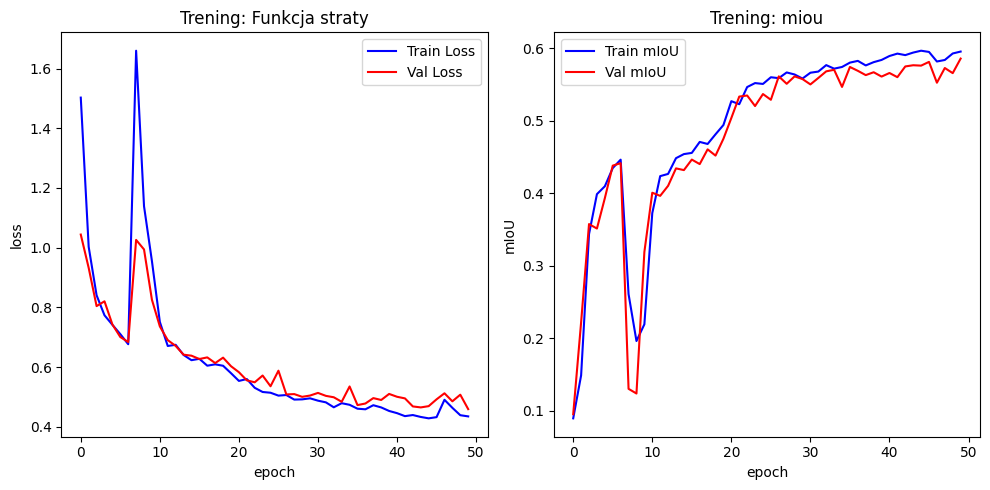

In [66]:
UNet_Aerial_trainer.show_history()

In [67]:
modelUnet.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = modelUnet(images)          # [B, 6, H, W]
    preds = torch.argmax(logits, dim=1) # [B, H, W]

print("images:", images.shape)
print("masks:", masks.shape)
print("logits:", logits.shape)
print("preds:", preds.shape)

print("Mask unique:", masks.unique())
print("Pred unique:", preds.unique())

images: torch.Size([8, 3, 256, 256])
masks: torch.Size([8, 256, 256])
logits: torch.Size([8, 6, 256, 256])
preds: torch.Size([8, 256, 256])
Mask unique: tensor([0, 1, 2, 3, 5], device='cuda:0')
Pred unique: tensor([0, 1, 2, 3, 4], device='cuda:0')


In [68]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    0: (60, 16, 152),     # Building
    1: (132, 41, 246),    # Land
    2: (110, 193, 228),   # Road
    3: (254, 221, 58),    # Vegetation
    4: (226, 169, 41),    # Water
    5: (155, 155, 155),   # Unlabeled
}


def class_mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_idx, color in CLASS_COLORS.items():
        rgb[mask == class_idx] = color

    return rgb

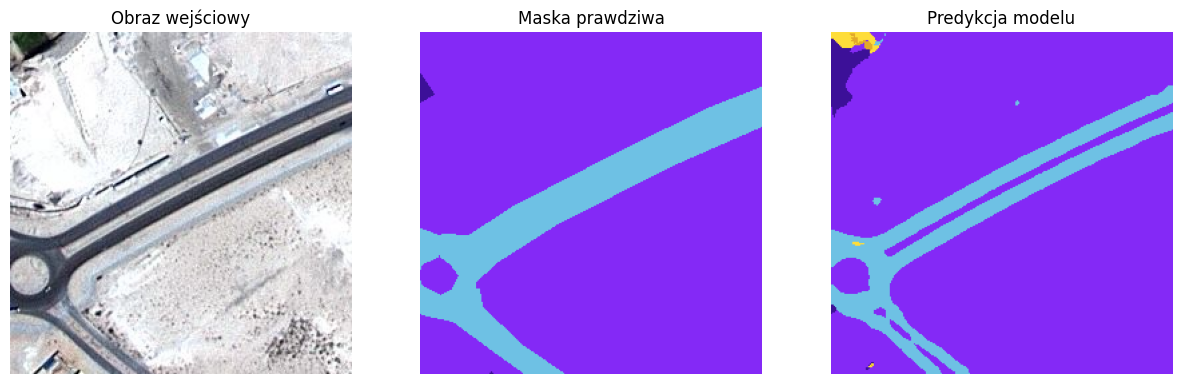

In [69]:
idx = 0

image_np = images[idx].detach().cpu().permute(1, 2, 0).numpy()
mask_np = masks[idx].detach().cpu().numpy()
pred_np = preds[idx].detach().cpu().numpy()

mask_rgb = class_mask_to_rgb(mask_np)
pred_rgb = class_mask_to_rgb(pred_np)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Obraz wejściowy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.title("Maska prawdziwa")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_rgb)
plt.title("Predykcja modelu")
plt.axis("off")

plt.show()